<a href="https://colab.research.google.com/github/garvjain7/ai-ml-deeplearning-masterclass/blob/main/aiMasterclass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***5 Days AI/ML and Deep Learning Master class***

***Day 1 - Basics, Neural networks and Backpropogation***

In [ ]:
from matplotlib.figure import Figure
import numpy as np # numerical python
import matplotlib.pyplot as plt # for visualization
import warnings
warnings.filterwarnings('ignore')

# Fix randomness
np.random.seed(42) # to get the fair and identical results everytime

# To get a better visuals
plt.rcParams.update({
    'figure.figsize':(11,4),
    'font.size':12,
    'axes.spines.top':False,
    'axes.spines.right':False
    })
print("Good to Go")

Good to Go


---
## Section 1: Why Do We Need Neural Networks?

### 🧩 Story

Imagine you're a doctor trying to diagnose whether a tumour is **malignant or benign**.
You have measurements: size, shape, texture, etc.

A simple rule might be: *"if radius > 15mm, it's probably malignant"*.

That works sometimes. But real cancer doesn't follow a single rule.
It's a **complex combination** of many measurements interacting together.

You need a model that can learn those complex combinations automatically.
That's a neural network.

---

### 🔴 The Problem with Logistic Regression (What You Already Know)

Logistic regression draws **one straight line** (or flat plane) to separate classes.

$$\hat{y} = \sigma(w_1 x_1 + w_2 x_2 + \ldots + b)$$

This completely fails when the boundary is curved or complex.

**Classic proof — XOR:**

| x₁ | x₂ | Output |
|---|---|---|
| 0 | 0 | 0 |
| 0 | 1 | **1** |
| 1 | 0 | **1** |
| 1 | 1 | 0 |

You cannot draw one straight line separating the 1s from the 0s. Try it.

---

### ✅ The Neural Network Solution: Stack Layers

Instead of one transformation, do several in sequence:

$$\hat{y} = f_3\!\Big(f_2\!\big(f_1(x)\big)\Big)$$

Each layer $f_i$ learns a different **view** of the data.
Later layers combine earlier views into complex patterns.

> 🧠 **Analogy — recognising a cat in a photo:**
> Layer 1 sees edges → Layer 2 sees shapes (ears, eyes) → Layer 3 says "that's a cat"
> Each layer only has to do a small, simple job.

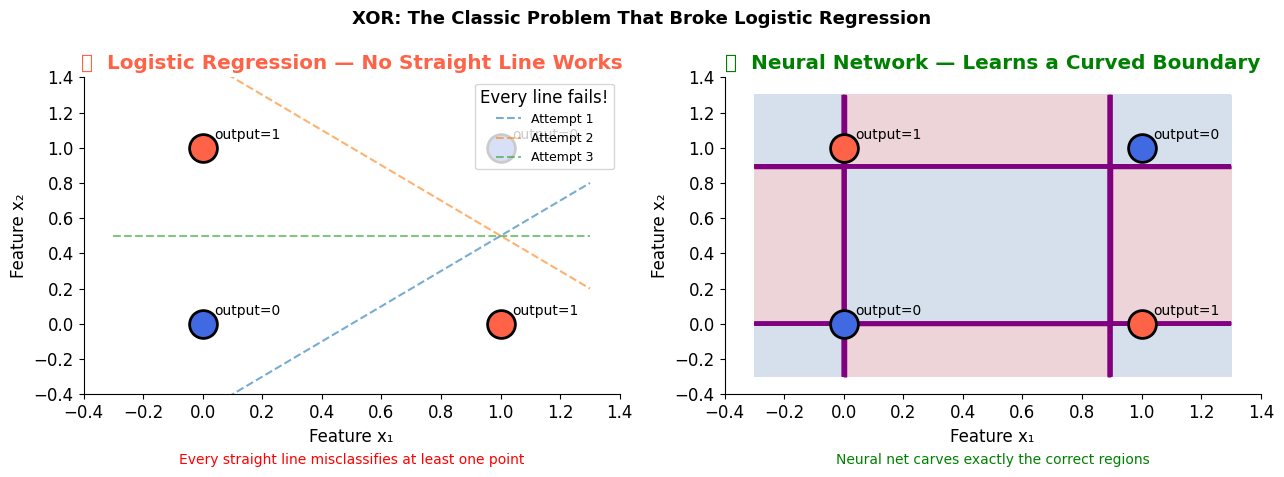

💡  The curved boundary is possible because of ACTIVATION FUNCTIONS.


In [ ]:
# ══════════════════════════════════════════════════════════════════
#  PICTURE: Why logistic regression cannot solve XOR
#  but a neural network can
# ══════════════════════════════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13,5))

# The four XOR data points
xor_points = [(0,0,0),(0,1,1),(1,0,1),(1,1,0)]  # (x1, x2, label)
colors = {0:'royalblue', 1:'tomato'}

for ax in [ax1, ax2]:
    for x1,x2,lbl in xor_points:
        ax.scatter(x1,x2, color=colors[lbl], s=400, zorder=5,
                   edgecolors='black', linewidths=2)
        ax.annotate(f"output={lbl}", (x1,x2),
                    xytext=(x1+0.04, x2+0.05), fontsize=10)
    ax.set_xlim(-0.4,1.4); ax.set_ylim(-0.4,1.4)
    ax.set_xlabel("Feature x₁"); ax.set_ylabel("Feature x₂")

# Left: show that NO straight line works
ax1.set_title("❌  Logistic Regression — No Straight Line Works",
              fontweight='bold', color='tomato')

xv = np.linspace(-0.3,1.3,100)
for s,b,name in [(1,-0.5,'Attempt 1'),(-1,1.5,'Attempt 2'),(0,0.5,'Attempt 3')]:
    ax1.plot(xv, s*xv+b, '--', alpha=0.6, label=name)
ax1.legend(title="Every line fails!", fontsize=9)
ax1.text(0.5,-0.22,
    "Every straight line misclassifies at least one point",
    ha='center', color='red', fontsize=10, transform=ax1.transAxes)

# Right: neural network draws a curved boundary
ax2.set_title("✅  Neural Network — Learns a Curved Boundary",
              fontweight='bold', color='green')
xx,yy = np.meshgrid(np.linspace(-0.3,1.3,200),np.linspace(-0.3,1.3,200))
grid  = np.c_[xx.ravel(),yy.ravel()]
Z = (np.sin(grid[:,0]*3.5)*np.sin(grid[:,1]*3.5)>0).reshape(xx.shape).astype(float)
ax2.contourf(xx,yy,Z, alpha=0.18, cmap='RdBu')
ax2.contour( xx,yy,Z, colors='purple', linewidths=2.5)
ax2.text(0.5,-0.22,
    "Neural net carves exactly the correct regions",
    ha='center', color='green', fontsize=10, transform=ax2.transAxes)

plt.suptitle("XOR: The Classic Problem That Broke Logistic Regression",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡  The curved boundary is possible because of ACTIVATION FUNCTIONS.")

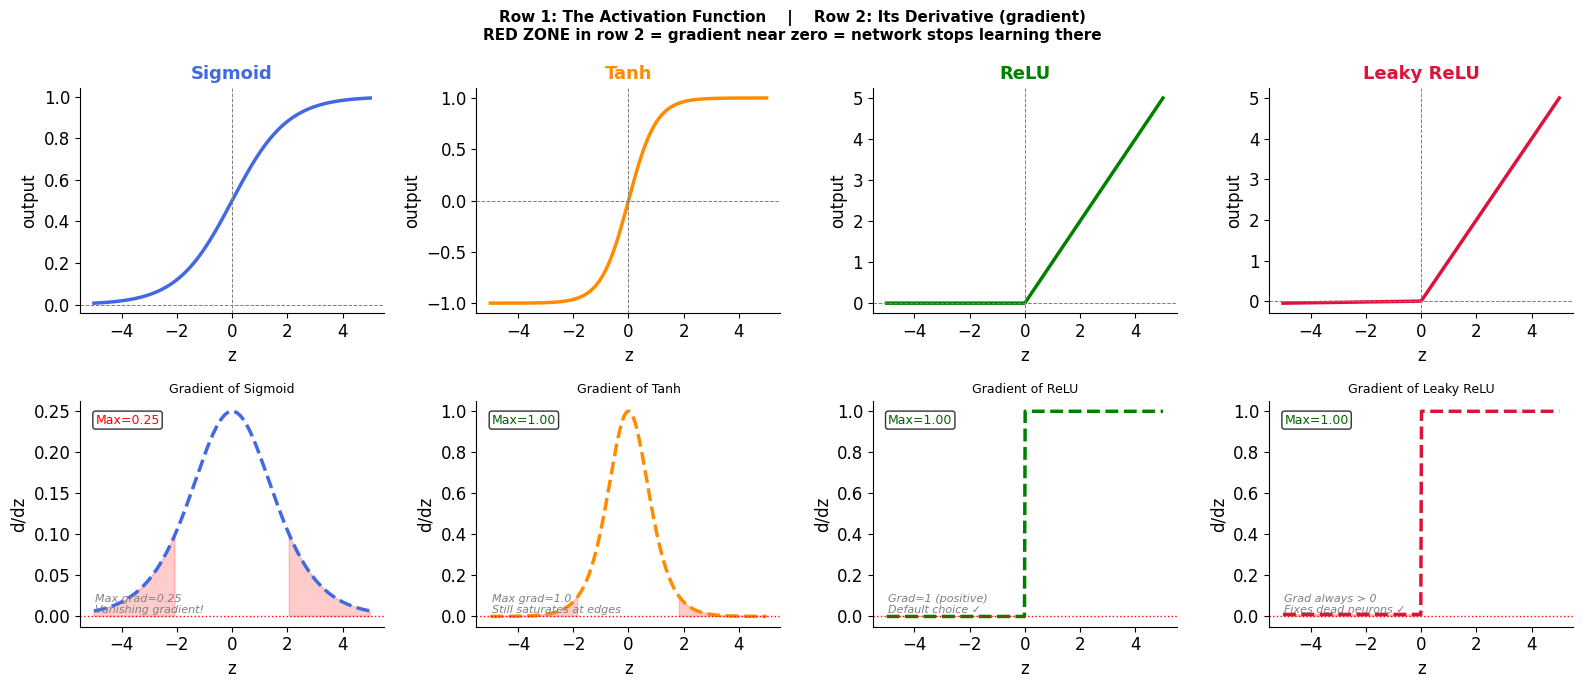


📌 TAKEAWAY:
  Sigmoid hidden layers → gradient shrinks to 0.25 each layer → vanishes fast
  ReLU hidden layers    → gradient stays 1.0 (positive side) → flows freely


In [ ]:
# ══════════════════════════════════════════════════════════════════
#  Define the 4 activation functions.
#  Each one also returns its DERIVATIVE — needed for backpropagation.
#
#  WHY do we need derivatives?
#  → Backprop multiplies gradient by the derivative at each layer.
#  → If derivative ≈ 0 everywhere → gradient vanishes → no learning.
#  → This is called the VANISHING GRADIENT problem.
# ══════════════════════════════════════════════════════════════════

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_grad(z):
    s = sigmoid(z)
    return s * (1 - s)          # Max value = 0.25  ← this is the problem

def tanh_act(z):
    return np.tanh(z)

def tanh_grad(z):
    return 1 - np.tanh(z)**2    # Max value = 1.0  ← better

def relu(z):
    return np.maximum(0, z)

def relu_grad(z):
    return (z > 0).astype(float) # 1 if positive, 0 if negative

def leaky_relu(z, a=0.01):
    return np.where(z > 0, z, a*z)

def leaky_relu_grad(z, a=0.01):
    return np.where(z > 0, 1.0, a)  # Never zero ← fixes dying ReLU


# ══════════════════════════════════════════════════════════════════
#  PICTURE: Show each function AND its derivative side by side.
#
#  The DERIVATIVE row is the most important:
#  → Red shaded zone = derivative near 0 = learning stops there.
#  → The bigger and flatter the derivative, the better learning flows.
# ══════════════════════════════════════════════════════════════════

z = np.linspace(-5, 5, 400)

configs = [
    (sigmoid,     sigmoid_grad,     'Sigmoid',     'royalblue',
     'Max grad=0.25\nVanishing gradient!'),
    (tanh_act,    tanh_grad,        'Tanh',        'darkorange',
     'Max grad=1.0\nStill saturates at edges'),
    (relu,        relu_grad,        'ReLU',        'green',
     'Grad=1 (positive)\nDefault choice ✓'),
    (leaky_relu,  leaky_relu_grad,  'Leaky ReLU',  'crimson',
     'Grad always > 0\nFixes dead neurons ✓'),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle(
    """Row 1: The Activation Function    |    Row 2: Its Derivative (gradient)
RED ZONE in row 2 = gradient near zero = network stops learning there""",
    fontsize=11, fontweight='bold')

for col,(fn,fd,name,c,note) in enumerate(configs):
    # ── Row 1: the activation ──────────────────────────────────
    ax = axes[0,col]
    ax.plot(z, fn(z), color=c, lw=2.5)
    ax.axhline(0, color='gray', lw=0.7, ls='--')
    ax.axvline(0, color='gray', lw=0.7, ls='--')
    ax.set_title(name, fontweight='bold', color=c, fontsize=13)
    ax.set_xlabel('z'); ax.set_ylabel('output')

    # ── Row 2: the derivative ──────────────────────────────────
    ax2 = axes[1,col]
    gv = fd(z)
    ax2.plot(z, gv, color=c, lw=2.5, ls='--')
    ax2.fill_between(z, gv, 0,
                     where=(np.abs(gv)<0.1),
                     color='red', alpha=0.2, label='Danger zone')
    ax2.axhline(0, color='red', lw=1, ls=':')
    ax2.set_xlabel('z'); ax2.set_ylabel("d/dz")
    ax2.set_title(f'Gradient of {name}', fontsize=9)
    mg = np.max(np.abs(gv))
    ax2.text(0.05, 0.90, f'Max={mg:.2f}',
             transform=ax2.transAxes, fontsize=9,
             color='darkgreen' if mg>=0.9 else 'red',
             bbox=dict(boxstyle='round,pad=0.2',facecolor='white',alpha=0.8))
    ax2.text(0.05, 0.06, note, transform=ax2.transAxes,
             fontsize=8, color='gray', style='italic')

plt.tight_layout(); plt.show()

print("\n📌 TAKEAWAY:")
print("  Sigmoid hidden layers → gradient shrinks to 0.25 each layer → vanishes fast")
print("  ReLU hidden layers    → gradient stays 1.0 (positive side) → flows freely")

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  LOSS FUNCTIONS
#  Simple implementations, each with a "why" comment.
# ══════════════════════════════════════════════════════════════════

def binary_cross_entropy(y_pred, y_true, eps=1e-8):
    """
    Binary Cross-Entropy — use for YES/NO classification tasks.

    The log() function is the key ingredient:
      • Predicting 0.99 when true=1  → -log(0.99) ≈ 0.01   tiny penalty
      • Predicting 0.50 when true=1  → -log(0.50) ≈ 0.69   moderate
      • Predicting 0.01 when true=1  → -log(0.01) ≈ 4.60   HUGE penalty

    Confident wrong answers are penalised catastrophically.
    This is why neural networks learn to be genuinely confident.

    eps: clips predictions away from 0 and 1 to avoid log(0) = -infinity.
    """
    y_pred = np.clip(y_pred, eps, 1-eps)
    return -np.mean(y_true * np.log(y_pred) + (1-y_true) * np.log(1-y_pred))

def mse_loss(y_pred, y_true):
    """Mean Squared Error — use for predicting a continuous number."""
    return np.mean((y_pred - y_true)**2)


# ══════════════════════════════════════════════════════════════════
#  DEMO: Show concretely why BCE beats MSE for classification.
# ══════════════════════════════════════════════════════════════════

print("  How different loss functions penalise a wrong prediction")
print("  (True label = 1  in all rows below)")
print()
print(f"  {'Scenario':<32} {'Prediction':>12} {'MSE':>8} {'BCE':>10}")
print("  " + "─"*65)

rows = [
    ("Correct & very confident",      0.99),
    ("Correct but uncertain",          0.60),
    ("Wrong — uncertain",              0.40),
    ("Wrong & very confident",         0.01),
]
for desc, p in rows:
    m = mse_loss(np.array([p]),   np.array([1.0]))
    b = binary_cross_entropy(np.array([p]), np.array([1.0]))
    flag = "  ← BCE screams here!" if p < 0.1 else ""
    print(f"  {desc:<32} {p:>12.2f} {m:>8.3f} {b:>10.3f}{flag}")

print()
print("  💡  For 'Wrong & very confident': BCE is 4.7× larger than MSE.")
print("      This aggressive penalty forces the network to really learn,")
print("      not just get 'close enough'.")

  How different loss functions penalise a wrong prediction
  (True label = 1  in all rows below)

  Scenario                           Prediction      MSE        BCE
  ─────────────────────────────────────────────────────────────────
  Correct & very confident                 0.99    0.000      0.010
  Correct but uncertain                    0.60    0.160      0.511
  Wrong — uncertain                        0.40    0.360      0.916
  Wrong & very confident                   0.01    0.980      4.605  ← BCE screams here!

  💡  For 'Wrong & very confident': BCE is 4.7× larger than MSE.
      This aggressive penalty forces the network to really learn,
      not just get 'close enough'.


In [ ]:
# ══════════════════════════════════════════════════════════════════
#  NEURAL NETWORK — COMPLETE, READABLE IMPLEMENTATION
#
#  This is the whole thing: weights, forward pass, backward pass,
#  weight update — in one class, every line commented.
#
#  Don't be scared by the length. Each method is only ~10 lines.
# ══════════════════════════════════════════════════════════════════

class SimpleNeuralNet:
    """
    A fully connected neural network using only NumPy.

    layer_sizes : list like [2, 4, 1]
        Means: 2 inputs → 4 hidden neurons → 1 output neuron
    lr : learning rate (step size, explained more in Day 2)
    """

    def __init__(self, layer_sizes, lr=0.1):
        self.sizes = layer_sizes
        self.lr    = lr
        self.L     = len(layer_sizes) - 1   # number of weight layers
        self.params = {}     # will hold W1,b1, W2,b2, ...
        self.cache  = {}     # will hold Z1,A1, Z2,A2, ... during forward pass
        self.history = []    # loss at each training step
        self._init_weights()

    # ── Step 0: Initialise weights ─────────────────────────────
    def _init_weights(self):
        """
        WHY NOT start all weights at zero?
        → Every neuron would compute the same thing.
          Every gradient would be equal. Every update identical.
          The network would never learn different features.
          (This is called the "symmetry problem".)

        WHY small random values?
        → Each neuron starts slightly different → can specialise.
        → Small values prevent activations from saturating immediately.

        (Day 2 covers much better initialisation: Xavier and He.)
        """
        np.random.seed(42)
        for l in range(1, self.L+1):
            n_in  = self.sizes[l-1]
            n_out = self.sizes[l]
            self.params[f'W{l}'] = np.random.randn(n_out, n_in) * 0.01
            self.params[f'b{l}'] = np.zeros((n_out, 1))

    # ── Step 1: Forward pass ───────────────────────────────────
    def forward(self, X):
        """
        Pass data from left (input) to right (output).
        At each layer: Z = W·A_prev + b,  then  A = activation(Z)
        Save everything — backprop will need it.
        """
        self.cache['A0'] = X
        A = X

        # Hidden layers use ReLU (WHY ReLU: gradient stays 1, not 0.25)
        for l in range(1, self.L):
            Z = self.params[f'W{l}'] @ A + self.params[f'b{l}']
            A = relu(Z)
            self.cache[f'Z{l}'] = Z   # saved for backprop
            self.cache[f'A{l}'] = A   # saved for backprop

        # Output layer uses Sigmoid (WHY: outputs a probability 0–1)
        Z = self.params[f'W{self.L}'] @ A + self.params[f'b{self.L}']
        A = sigmoid(Z)
        self.cache[f'Z{self.L}'] = Z
        self.cache[f'A{self.L}'] = A
        return A   # prediction, shape (1, n_samples)

    # ── Step 2: Backward pass ──────────────────────────────────
    def backward(self, y):
        """
        Trace the error backwards to find each weight's contribution.
        Returns a dict of gradients: dW1, db1, dW2, db2, ...
        """
        m = y.shape[1]    # number of training samples
        grads = {}

        # Output layer: for sigmoid + BCE loss, the gradient is simply ŷ - y
        # (The sigmoid and log derivatives cancel out neatly — a lucky coincidence)
        delta = self.cache[f'A{self.L}'] - y

        grads[f'dW{self.L}'] = (1/m) * delta @ self.cache[f'A{self.L-1}'].T
        grads[f'db{self.L}'] = (1/m) * np.sum(delta, axis=1, keepdims=True)

        # Hidden layers: propagate error backwards using chain rule
        for l in range(self.L-1, 0, -1):
            # Route error back through this layer's weights (transpose = reverse direction)
            # Then mask by which neurons were active (relu_grad)
            delta = (self.params[f'W{l+1}'].T @ delta) * relu_grad(self.cache[f'Z{l}'])

            grads[f'dW{l}'] = (1/m) * delta @ self.cache[f'A{l-1}'].T
            grads[f'db{l}'] = (1/m) * np.sum(delta, axis=1, keepdims=True)

        return grads

    # ── Step 3: Update weights ─────────────────────────────────
    def update(self, grads):
        """
        Move each weight in the direction that reduces loss.
        W = W - lr * gradient

        WHY subtract?
        Gradient points toward HIGHER loss.
        We want LOWER loss → go the opposite way.

        WHY multiply by lr (learning rate)?
        Controls how big a step we take.
        Too large → overshoot. Too small → too slow.
        Day 2 covers how to choose this well.
        """
        for l in range(1, self.L+1):
            self.params[f'W{l}'] -= self.lr * grads[f'dW{l}']
            self.params[f'b{l}'] -= self.lr * grads[f'db{l}']

    # ── Full training loop ─────────────────────────────────────
    def train(self, X, y, epochs=5000, verbose=True):
        """
        Repeat: forward → compute loss → backward → update.
        WHY many epochs? One pass adjusts weights slightly.
        Thousands of passes → converge to a good solution.
        """
        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss   = binary_cross_entropy(y_pred.flatten(), y.flatten())
            self.history.append(loss)
            grads  = self.backward(y)
            self.update(grads)
            if verbose and epoch % (epochs//5) == 0:
                acc = (y_pred.round() == y).mean() * 100
                print(f"  Epoch {epoch:>6} | Loss: {loss:.4f} | Accuracy: {acc:.0f}%")

print("✅  SimpleNeuralNet ready!")
print()
print("  Three steps per training iteration:")
print("  1. forward()  — make a prediction")
print("  2. backward() — trace the error to each weight")
print("  3. update()   — nudge weights toward lower loss")

✅  SimpleNeuralNet ready!

  Three steps per training iteration:
  1. forward()  — make a prediction
  2. backward() — trace the error to each weight
  3. update()   — nudge weights toward lower loss


---
## Section 5: 💻 Live Demo — Watch the Network Learn

We'll train our network on XOR.
- Epoch 0: accuracy around 50% (random guessing)
- By epoch 5000: accuracy should reach **100%**

This is backpropagation working in real time!

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  XOR DATASET
#  Columns are samples, rows are features (numpy convention)
# ══════════════════════════════════════════════════════════════════

X_xor = np.array([[0,0,1,1],
                   [0,1,0,1]])   # shape (2, 4)

y_xor = np.array([[0,1,1,0]])   # shape (1, 4) — true XOR output

# Architecture: 2 inputs → 4 hidden neurons → 1 output
# Why 4 hidden neurons? XOR only needs ~2, but 4 gives more room to learn.
net = SimpleNeuralNet(layer_sizes=[2, 4, 1], lr=0.5)

print("Training on XOR (watch loss fall, accuracy rise to 100%):")
print("─"*52)
net.train(X_xor, y_xor, epochs=5001)

print("─"*52)
print("\nFinal predictions:")
print(f"  {'(x1,x2)':<10} {'True':>6} {'Predicted Prob':>16} {'Decision':>10}")
print("  " + "─"*46)
preds = net.forward(X_xor)
for i in range(4):
    x1,x2 = X_xor[0,i], X_xor[1,i]
    true  = int(y_xor[0,i])
    prob  = float(preds[0,i])
    pred  = int(prob > 0.5)
    ok    = "✅" if pred==true else "❌"
    print(f"  ({x1},{x2})       {true:>6}    {prob:>10.4f}     {pred}  {ok}")

Training on XOR (watch loss fall, accuracy rise to 100%):
────────────────────────────────────────────────────
  Epoch      0 | Loss: 0.6931 | Accuracy: 75%
  Epoch   1000 | Loss: 0.0062 | Accuracy: 100%
  Epoch   2000 | Loss: 0.0023 | Accuracy: 100%
  Epoch   3000 | Loss: 0.0014 | Accuracy: 100%
  Epoch   4000 | Loss: 0.0010 | Accuracy: 100%
  Epoch   5000 | Loss: 0.0008 | Accuracy: 100%
────────────────────────────────────────────────────

Final predictions:
  (x1,x2)      True   Predicted Prob   Decision
  ──────────────────────────────────────────────
  (0,0)            0        0.0022     0  ✅
  (0,1)            1        0.9997     1  ✅
  (1,0)            1        0.9997     1  ✅
  (1,1)            0        0.0002     0  ✅


***DAY - 2 of AI/ML Masterclass***

***Training Deep Networks: Optimisers, Initialisation & Regularisation***

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split # For splitting
from sklearn.preprocessing import StandardScaler # For scaling
from sklearn.neural_network import MLPClassifier # For Classification
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix # reports
import warnings
warnings.filterwarnings('ignore')
print("Everything loaded successfully")

Everything loaded successfully


In [ ]:
data = load_breast_cancer()

# Separate data for splitting
x = data.data # X is Input features → 30 measurements for each patient ex. Cell, Size, Shape
y = data.target # Target labels → 0 = Malignant, 1 = Benign

print(f'📊 Dataset shape : {X.shape}') # Shows (number of samples, number of features) 569 patients, 30 features

print(f'🔴 Malignant (0) : {(y==0).sum()} patients') # Count how many patients have malignant cancer

print(f'🟢 Benign   (1) : {(y==1).sum()} patients')# Count how many patients have benign cancer y==1 checking how many 0 are there.. sum()total count

📊 Dataset shape : (569, 30)
🔴 Malignant (0) : 212 patients
🟢 Benign   (1) : 357 patients


In [ ]:
# Splitting the data for training and testing using [train_test_split]
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
    )
print("Split Successful")

Split Successful


In [ ]:
# ── StandardScaler: makes mean=0, std=1 for every feature ───────────────────
#Scaling ensures fair learning by bringing all features to the same scale.
scaler = StandardScaler()
# Create scaler → used to normalize data
#like if theory marks is out of 100 and practical is out of 50 so we can't Compare
#first need to make a range after that we can normalize

x_train_scaled = scaler.fit_transform(x_train) # never fit on "testing data"
x_test_scaled = scaler.transform(x_test) # # Only transform test data (DO NOT fit again → avoids data leakage)

print('BEFORE scaling — first feature (mean radius):')
print(f'  Min={x_train[:,0].min():.2f},  Max={x_train[:,0].max():.2f}')
# Original range means to check theory 100 and practical 50
# break this line into four parts: Print for output on screen
#f'...' it is a string in which now we can store the variable into this string.
#X_train[:,0] this is for indexing as we are selecting a specific column of data : all rows, 0 first column.
#.min() → smallest value .max() → largest value pointing minimum and maximum value of column.
#.2 → 2 decimal places, f → float number x = 3.14159 output= 3.14
#We are taking first feature's min and max value to print from training data formatted to 2 decimal places.


print('\nAFTER scaling:')
print(f'  Min={x_train_scaled[:,0].min():.2f},  Max={x_train_scaled[:,0].max():.2f}')
# Scaled range value is now minimum and in same range to use

print(f'  Mean={x_train_scaled[:,0].mean():.2f} (approx 0) ✅')
# Mean becomes ~0 after scaling means scaling is successful now.

BEFORE scaling — first feature (mean radius):
  Min=7.69,  Max=28.11

AFTER scaling:
  Min=-1.82,  Max=3.96
  Mean=-0.00 (approx 0) ✅


In [ ]:
# ── Compare Optimisers ───────────────────────────────────────────────────────
# We train 3 small networks, same architecture, different optimisers

results = {}  # store accuracy for each

# ---- 1. SGD (vanilla) -------------------------------------------------------
sgd_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # 2 hidden layers
    solver='sgd',                  # Stochastic Gradient Descent
    learning_rate_init=0.01,
    max_iter=200,
    random_state=42
)
sgd_model.fit(x_train_scaled, y_train)
results['SGD'] = accuracy_score(y_test, sgd_model.predict(x_test_scaled))
print(f'🐢 SGD Accuracy         : {results["SGD"]*100:.1f}%')

# ---- 2. SGD with Momentum ---------------------------------------------------
mom_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    solver='sgd',
    momentum=0.9,                  # adds momentum (snowball effect)
    learning_rate_init=0.01,
    max_iter=200,
    random_state=42
)
mom_model.fit(x_train_scaled, y_train)
results['SGD+Momentum'] = accuracy_score(y_test, mom_model.predict(x_test_scaled))
print(f'⚡ SGD+Momentum Accuracy : {results["SGD+Momentum"]*100:.1f}%')

# ---- 3. Adam ----------------------------------------------------------------
adam_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    solver='adam',                 # Adaptive Moment Estimation
    learning_rate_init=0.001,
    max_iter=200,
    random_state=42
)
adam_model.fit(x_train_scaled, y_train)
results['Adam'] = accuracy_score(y_test, adam_model.predict(x_test_scaled))
print(f'🚀 Adam Accuracy         : {results["Adam"]*100:.1f}%')

🐢 SGD Accuracy         : 97.4%
⚡ SGD+Momentum Accuracy : 97.4%
🚀 Adam Accuracy         : 97.4%


**Plotting optimiser comparison**

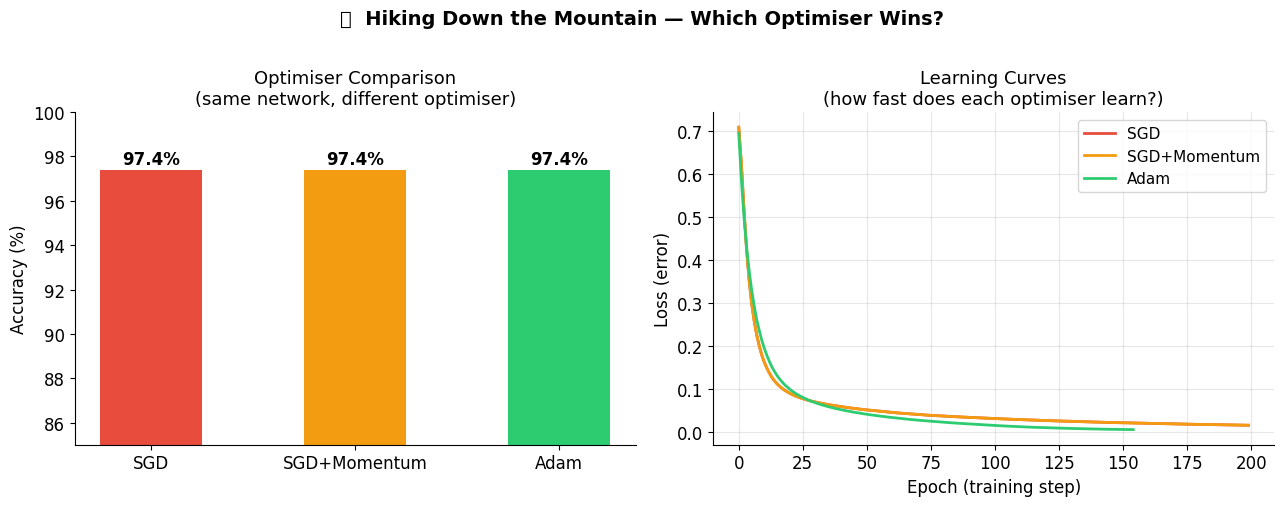


💡 KEY INSIGHT: Adam usually converges faster and reaches lower loss!


In [ ]:
# ── Plot: Optimiser Comparison ───────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# Create 2 plots side by side Left → Accuracy Right → Learning curve


# ── Bar chart: Accuracy comparison ──────────────────────────────────────────

colors = ['#e74c3c', '#f39c12', '#2ecc71']
# Colors for each optimizer

bars = axes[0].bar(
    results.keys(),
    [v*100 for v in results.values()],
    color=colors,
    width=0.5
)
# Plot accuracy (converted to percentage)
#axes[0].bar bars that Comapres each optimizers accuracy
#v*100 for v in results.values() convert accuracy to percentage


axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Optimiser Comparison\n(same network, different optimiser)', fontsize=13)
axes[0].set_ylim(85, 100)
# Set y-axis range

# Add value labels on top of bars
for bar, val in zip(bars, results.values()): # Graph,s columns (rectangles); results.values()Accuracy values (numbers)
# zip() pair both list in one; With each bars it pairs its values and execute the loop.
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f'{val*100:.1f}%',
        ha='center',
        va='bottom',
        fontweight='bold'
    )
#axes[0].text(...) To write the text on graph
#bar.get_x() →  X Position where to write text horizontalbar's starting point; bar.get_width() → bar's width; width/2 → center
#bar.get_height() + 0.1 for vertical height
#  f'{val*100:.1f}%' Shows exact accuracy on each bars to show clearly which optimizer is working best.
#val → 0.91; val * 100 → 91; :.1f → 1 decimal Change value into percentage

# We are placing formatted accuracy values exactly at the top-center of each bar.

# ── Line plot: Loss curves ──────────────────────────────────────────────────

for model, label, color in [
    (sgd_model, 'SGD', '#e74c3c'),
    (mom_model, 'SGD+Momentum', '#f39c12'),
    (adam_model, 'Adam', '#2ecc71')
]:
    axes[1].plot(model.loss_curve_, label=label, color=color, linewidth=2)
# Plot how loss decreases over training

axes[1].set_xlabel('Epoch (training step)', fontsize=12)
axes[1].set_ylabel('Loss (error)', fontsize=12)
axes[1].set_title('Learning Curves\n(how fast does each optimiser learn?)', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# ── Final layout ────────────────────────────────────────────────────────────

plt.suptitle('🏔️  Hiking Down the Mountain — Which Optimiser Wins?',
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('optimiser_comparison.png', dpi=120, bbox_inches='tight')
# Save the plot as image

plt.show()

print('\n💡 KEY INSIGHT: Adam usually converges faster and reaches lower loss!')

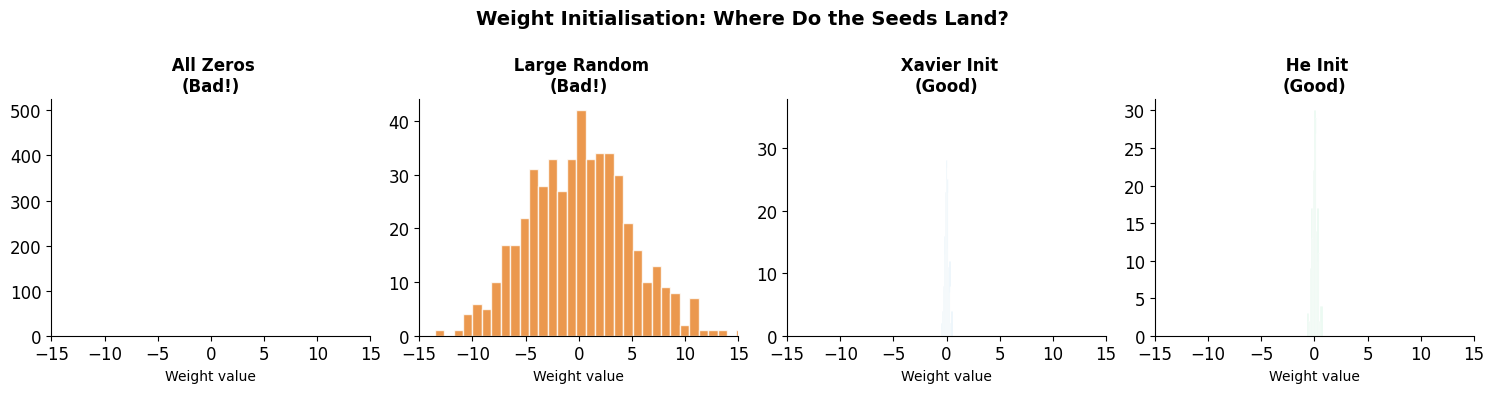


💡 KEY INSIGHT:
   • All zeros → all neurons are identical → network cannot learn different features
   • Too large  → signals explode through layers
   • Xavier/He  → signals flow smoothly → network learns efficiently


In [ ]:
# ── Visualise Weight Initialisation Distributions ────────────────────────────
np.random.seed(42)
n_neurons = 500 # We are generating 500 neurons weights with fix seed so to get same output

# Different init strategies
zeros_init  = np.zeros(n_neurons)                        # All zero (bad!) every weight is zero here graph will be streight line and identical where no learning happens.
random_init = np.random.randn(n_neurons) * 5             # Large random (bad!) random values with large entity graph Values more spread out (−15 se +15) ; Signals explode
xavier_init = np.random.randn(n_neurons) * np.sqrt(1/30) # Xavier (good!) Stable at centre 0
he_init     = np.random.randn(n_neurons) * np.sqrt(2/30) # He     (good!) For ReLU optimized initialization graph will be Better gradient flow for deep networks

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

configs = [
    (zeros_init,  'All Zeros\n(Bad!)',  '#e74c3c', ''),
    (random_init, 'Large Random\n(Bad!)', '#e67e22', ''),
    (xavier_init, 'Xavier Init\n(Good)', '#3498db', ''),
    (he_init,     'He Init\n(Good)',    '#2ecc71', ''),
]

for ax, (data_init, title, color, emoji) in zip(axes, configs):
    ax.hist(data_init, bins=40, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'{emoji} {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Weight value', fontsize=10)
    ax.set_xlim(-15, 15)

plt.suptitle('Weight Initialisation: Where Do the Seeds Land?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('init_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n💡 KEY INSIGHT:')
print('   • All zeros → all neurons are identical → network cannot learn different features')
print('   • Too large  → signals explode through layers')
print('   • Xavier/He  → signals flow smoothly → network learns efficiently')

***Mini Project***

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
#from sklearn.datasets import load_wine # three hidden layers can overfit on this
#from sklearn.datasets import load_digits # scaling is not ideal here, because its an image dataset, in which first pixel is always 0
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')
print("All set")

All set


In [ ]:
x, y = make_classification(
    n_samples=5000,
    n_features=20,
    n_informative=15,
    n_classes=3,
    random_state=42
)
print("Data is imported")

Data is imported


In [ ]:
# splitting the dataset for training and testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# scaling the data
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
print("Splitting and scaling successful")

print(f'BEFORE scaling — first feature (mean radius):')
print(f'  Min={x_train[:,0].min():.2f},  Max={x_train[:,0].max():.2f}')
print(f'  Mean={x_train[:,0].mean():.2f}')

print(f'\nAFTER scaling:')
print(f'  Min={x_train_scaled[:,0].min():.2f},  Max={x_train_scaled[:,0].max():.2f}')
print(f'  Mean={x_train_scaled[:,0].mean():.2f}')

Splitting and scaling successful
BEFORE scaling — first feature (mean radius):
  Min=-22.78,  Max=23.00
  Mean=-0.13

AFTER scaling:
  Min=-3.84,  Max=3.92
  Mean=-0.00


In [ ]:
# Comparing two optimizers
# 3 small neural networks, same architecture, different optimizer
# a) SGD
# b) SGD + Momentum
# c) adam

results = {}  # store accuracy for each optimizer in the results dictionary

# -------------------- SGD -----------------------
sgd_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    solver='sgd',
    learning_rate_init=0.1,
    max_iter=200,
    random_state=42
)
sgd_model.fit(x_train_scaled, y_train)
results['sgd'] = accuracy_score(y_test, sgd_model.predict(x_test_scaled))
print(f'SGD accuracy: {results['sgd']*100:.2f}%')

sgdm_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    solver='sgd',
    learning_rate_init=0.1,
    max_iter=200,
    random_state=42
)
sgdm_model.fit(x_train_scaled, y_train)
results['sgdm'] = accuracy_score(y_test, sgdm_model.predict(x_test_scaled))
print(f'SGDM accuracy: {results['sgdm']*100:.2f}%')

adam_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    solver='adam',
    learning_rate_init=0.001,
    max_iter=200,
    random_state=42
)
adam_model.fit(x_train_scaled, y_train)
results['adam'] = accuracy_score(y_test, adam_model.predict(x_test_scaled))
print(f'Adam accuracy: {results['adam']*100:.2f}%')

SGD accuracy: 94.60%
SGDM accuracy: 94.60%
Adam accuracy: 93.80%


***DAY 3 - Natural Language Processing(NLP) by "Deepak Arora"***